In [1]:
import pandas as pd
import numpy as np
import warnings
from ydata_profiling import ProfileReport
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns

/tmp/ipykernel_1341/2588687726.py:4: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [2]:
df_customer = pd.read_excel("/kaggle/input/datasets/samanenajarian/dataset/First Dataset.xlsx")
df_customer.head()

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
0,1001,Reza,F,19.0,Karaj,Alborz,2025-02-19,VIP,17,121.53,2066.01,16,Card,Android,Yes,3,5
1,1002,Sina,M,53.0,Tehran,Tehran,2022-08-19,Gold,12,326.47,3917.64,3,Card,Web,No,5,3
2,1003,Parsa,F,31.0,Shiraz,Fars,2023-06-20,Gold,21,59.46,1248.66,22,Online Wallet,iPhone,Yes,6,1
3,1004,Sina,F,58.0,Mashhad,Khorasan,2021-11-08,Gold,23,266.15,6121.45,40,Card,Android,No,4,4
4,1005,Kimia,M,28.0,Isfahan,Isfahan,2021-10-21,Silver,23,169.54,3899.42,273,Online Wallet,Android,Yes,7,4


In [3]:
df_customer.shape

(61, 17)

In [4]:
df_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         61 non-null     int64  
 1   first_name          61 non-null     object 
 2   gender              61 non-null     object 
 3   age                 60 non-null     float64
 4   city                61 non-null     object 
 5   province            61 non-null     object 
 6   signup_date         61 non-null     object 
 7   membership_tier     61 non-null     object 
 8   purchase_count      61 non-null     int64  
 9   avg_order_value     61 non-null     float64
 10  total_spending      60 non-null     float64
 11  last_purchase_days  61 non-null     int64  
 12  payment_method      61 non-null     object 
 13  device              61 non-null     object 
 14  discount_used       61 non-null     object 
 15  returned_items      61 non-null     int64  
 16  satisfacti

<div style="
    background-color:#EAF2F8;
    padding:18px;
    border-radius:10px;
    border-left:8px solid #1F4E79;
    font-family:'Georgia', serif;
    color:#1F4E79;
    font-size:26px;
    font-weight:bold;
    text-align:center;
    letter-spacing:1px;">
    Data Preprocessing
</div>

In [5]:
#profile = ProfileReport(df_customer, title="Customer Satisfaction data EDA")
#profile

#profile.to_file("Customer Satisfaction data EDA.html")

In [6]:
Filtered_df = df_customer.copy()

In [7]:
Filtered_df['signup_date'] = pd.to_datetime(
    Filtered_df['signup_date']
)
Filtered_df['signup_year'] = Filtered_df['signup_date'].dt.year

Filtered_df['signup_month'] = Filtered_df['signup_date'].dt.month

Filtered_df = Filtered_df.drop(
    'signup_date',
    axis=1
)

In [8]:
duplicates = Filtered_df[Filtered_df.duplicated(keep=False)]
Filtered_df = Filtered_df.drop_duplicates(keep='first')

In [9]:
Filtered_df.drop(columns=['first_name'], inplace=True )
Filtered_df.set_index('customer_id', inplace=True)
Filtered_df.head()

,gender,age,city,province,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score,signup_year,signup_month
customer_id,,,,,,,,,,,,,,,,
1001,F,19.0,Karaj,Alborz,VIP,17,121.53,2066.01,16,Card,Android,Yes,3,5,2025,2
1002,M,53.0,Tehran,Tehran,Gold,12,326.47,3917.64,3,Card,Web,No,5,3,2022,8
1003,F,31.0,Shiraz,Fars,Gold,21,59.46,1248.66,22,Online Wallet,iPhone,Yes,6,1,2023,6
1004,F,58.0,Mashhad,Khorasan,Gold,23,266.15,6121.45,40,Card,Android,No,4,4,2021,11
1005,M,28.0,Isfahan,Isfahan,Silver,23,169.54,3899.42,273,Online Wallet,Android,Yes,7,4,2021,10


In [32]:
y = Filtered_df.iloc[:,-3]
X = Filtered_df.drop(Filtered_df.columns[-3],axis=1)
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=880)

<div style="
    background-color:#EAF2F8;
    padding:18px;
    border-radius:10px;
    border-left:8px solid #1F4E79;
    font-family:'Georgia', serif;
    color:#1F4E79;
    font-size:26px;
    font-weight:bold;
    text-align:center;
    letter-spacing:1px;">
    Handling Outliers
</div>

In [33]:
X_train_Cleaning = X_train.copy()
y_train_Cleaning = y_train.copy()

In [35]:
columns = X_train.columns

categorical_indices = [i for i , col in enumerate(X_train.columns) if X_train[col].dtype=='object']

categorical_fields = [columns[i] for i in categorical_indices]

continuous_fields = [j for j in columns if j not in categorical_fields]

continuous_df = X_train[continuous_fields]

In [36]:
Q1 = continuous_df.quantile(0.25)
Q3 = continuous_df.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = (continuous_df < lower) | (continuous_df > upper)

total_outliers = outliers.sum().sum()
total_values = continuous_df.size

percentage = (total_outliers / total_values) * 100

outlier_table = pd.DataFrame({
    "Feature": continuous_df.columns,
    "Outlier Count": outliers.sum().values,
    "Outlier Percentage (%)": (outliers.mean() * 100).round(2).values
})

outlier_table

,Feature,Outlier Count,Outlier Percentage (%)
0,age,0,0.00
1,purchase_count,0,0.00
2,avg_order_value,0,0.00
3,total_spending,5,10.42
4,last_purchase_days,0,0.00
5,returned_items,0,0.00
6,signup_year,0,0.00
7,signup_month,0,0.00


In [37]:
rows_with_outliers = continuous_df.loc[outliers.any(axis=1)]
rows_with_outliers

,age,purchase_count,avg_order_value,total_spending,last_purchase_days,returned_items,signup_year,signup_month
customer_id,,,,,,,,
1030,60.0,26,156.89,25000.00,340,4,2025,3
1044,64.0,33,434.98,14354.34,165,7,2024,7
1009,61.0,34,341.63,11615.42,232,8,2021,5
1057,58.0,31,436.54,13532.74,82,4,2024,6
1059,57.0,31,287.05,8898.55,224,0,2023,9


<div style="
    background-color:#EAF2F8;
    padding:18px;
    border-radius:10px;
    border-left:8px solid #1F4E79;
    font-family:'Georgia', serif;
    color:#1F4E79;
    font-size:26px;
    font-weight:bold;
    text-align:center;
    letter-spacing:1px;">
    Handling Missing Values
</div>

In [39]:
Cleaning_train = pd.concat([X_train_Cleaning, y_train_Cleaning], axis=1)
Cleaning_train.head()

,gender,age,city,province,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,signup_year,signup_month,satisfaction_score
customer_id,,,,,,,,,,,,,,,,
1026,M,19.0,Ahvaz,Khuzestan,Bronze,11,335.41,3689.51,195,Card,iPhone,Yes,3,2022,5,4
1058,F,47.0,Tehran,Tehran,Bronze,5,151.81,759.05,336,Online Wallet,iPhone,No,0,2024,9,2
1040,F,65.0,Tehran,Tehran,Bronze,34,37.66,NaN,126,Card,Android,Yes,3,2021,11,2
1030,M,60.0,Mashhad,Khorasan,VIP,26,156.89,25000.00,340,Cash,Web,Yes,4,2025,3,4
1008,F,23.0,Rasht,Gilan,VIP,3,389.58,1168.74,195,Online Wallet,iPhone,No,8,2024,10,1


In [43]:
Cleaning_train.shape

(48, 16)

In [44]:
Cleaning_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48 entries, 1026 to 1013
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   gender              48 non-null     object 
 1   age                 47 non-null     float64
 2   city                48 non-null     object 
 3   province            48 non-null     object 
 4   membership_tier     48 non-null     object 
 5   purchase_count      48 non-null     int64  
 6   avg_order_value     48 non-null     float64
 7   total_spending      47 non-null     float64
 8   last_purchase_days  48 non-null     int64  
 9   payment_method      48 non-null     object 
 10  device              48 non-null     object 
 11  discount_used       48 non-null     object 
 12  returned_items      48 non-null     int64  
 13  signup_year         48 non-null     int32  
 14  signup_month        48 non-null     int32  
 15  satisfaction_score  48 non-null     int64  
dtypes: float64

In [45]:
missing_values_report = pd.DataFrame({
    'Column': Cleaning_train.columns,
    'Missing Values': Cleaning_train.isnull().sum().values,
    'Percentage Missing': Cleaning_train.isnull().mean().values * 100
})

print("Missing Values Report:")
missing_values_report

Missing Values Report:


,Column,Missing Values,Percentage Missing
0,gender,0,0.000000
1,age,1,2.083333
2,city,0,0.000000
3,province,0,0.000000
4,membership_tier,0,0.000000
5,purchase_count,0,0.000000
6,avg_order_value,0,0.000000
7,total_spending,1,2.083333
8,last_purchase_days,0,0.000000
9,payment_method,0,0.000000


In [46]:
rows_with_missing = Cleaning_train[Cleaning_train.isna().any(axis=1)]
rows_with_missing

,gender,age,city,province,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,signup_year,signup_month,satisfaction_score
customer_id,,,,,,,,,,,,,,,,
1040,F,65.0,Tehran,Tehran,Bronze,34,37.66,NaN,126,Card,Android,Yes,3,2021,11,2
1020,M,NaN,Isfahan,Isfahan,Bronze,16,187.17,2994.72,4,Cash,Web,Yes,1,2024,6,5


In [47]:
Cleaning_train_missing_fix = Cleaning_train.copy()

missing_vars = ['age','total_spending']
imputer = SimpleImputer(strategy='mean') 
                                                     

Cleaning_train_missing_fix[missing_vars] = imputer.fit_transform(Cleaning_train_missing_fix[missing_vars])

print("DataFrame after Imputation:")
Cleaning_train_missing_fix

Cleaning_train_missing_fix.info()

DataFrame after Imputation:
<class 'pandas.core.frame.DataFrame'>
Index: 48 entries, 1026 to 1013
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   gender              48 non-null     object 
 1   age                 48 non-null     float64
 2   city                48 non-null     object 
 3   province            48 non-null     object 
 4   membership_tier     48 non-null     object 
 5   purchase_count      48 non-null     int64  
 6   avg_order_value     48 non-null     float64
 7   total_spending      48 non-null     float64
 8   last_purchase_days  48 non-null     int64  
 9   payment_method      48 non-null     object 
 10  device              48 non-null     object 
 11  discount_used       48 non-null     object 
 12  returned_items      48 non-null     int64  
 13  signup_year         48 non-null     int32  
 14  signup_month        48 non-null     int32  
 15  satisfaction_score  48 non-null

In [48]:
Cleaning_train_missing_fix.to_csv('/kaggle/working/Final_data.csv')

<div style="
    background-color:#EAF2F8;
    padding:18px;
    border-radius:10px;
    border-left:8px solid #1F4E79;
    font-family:'Georgia', serif;
    color:#1F4E79;
    font-size:26px;
    font-weight:bold;
    text-align:center;
    letter-spacing:1px;">
    Data Visualization
</div>

In [49]:
Final_data = pd.read_csv('/kaggle/working/Final_data.csv')
Final_data.head()

,customer_id,gender,age,city,province,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,signup_year,signup_month,satisfaction_score
0,1026,M,19.0,Ahvaz,Khuzestan,Bronze,11,335.41,3689.51000,195,Card,iPhone,Yes,3,2022,5,4
1,1058,F,47.0,Tehran,Tehran,Bronze,5,151.81,759.05000,336,Online Wallet,iPhone,No,0,2024,9,2
2,1040,F,65.0,Tehran,Tehran,Bronze,34,37.66,3637.97234,126,Card,Android,Yes,3,2021,11,2
3,1030,M,60.0,Mashhad,Khorasan,VIP,26,156.89,25000.00000,340,Cash,Web,Yes,4,2025,3,4
4,1008,F,23.0,Rasht,Gilan,VIP,3,389.58,1168.74000,195,Online Wallet,iPhone,No,8,2024,10,1


In [50]:
Final_data.shape

(48, 17)

In [51]:
Final_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         48 non-null     int64  
 1   gender              48 non-null     object 
 2   age                 48 non-null     float64
 3   city                48 non-null     object 
 4   province            48 non-null     object 
 5   membership_tier     48 non-null     object 
 6   purchase_count      48 non-null     int64  
 7   avg_order_value     48 non-null     float64
 8   total_spending      48 non-null     float64
 9   last_purchase_days  48 non-null     int64  
 10  payment_method      48 non-null     object 
 11  device              48 non-null     object 
 12  discount_used       48 non-null     object 
 13  returned_items      48 non-null     int64  
 14  signup_year         48 non-null     int64  
 15  signup_month        48 non-null     int64  
 16  satisfacti

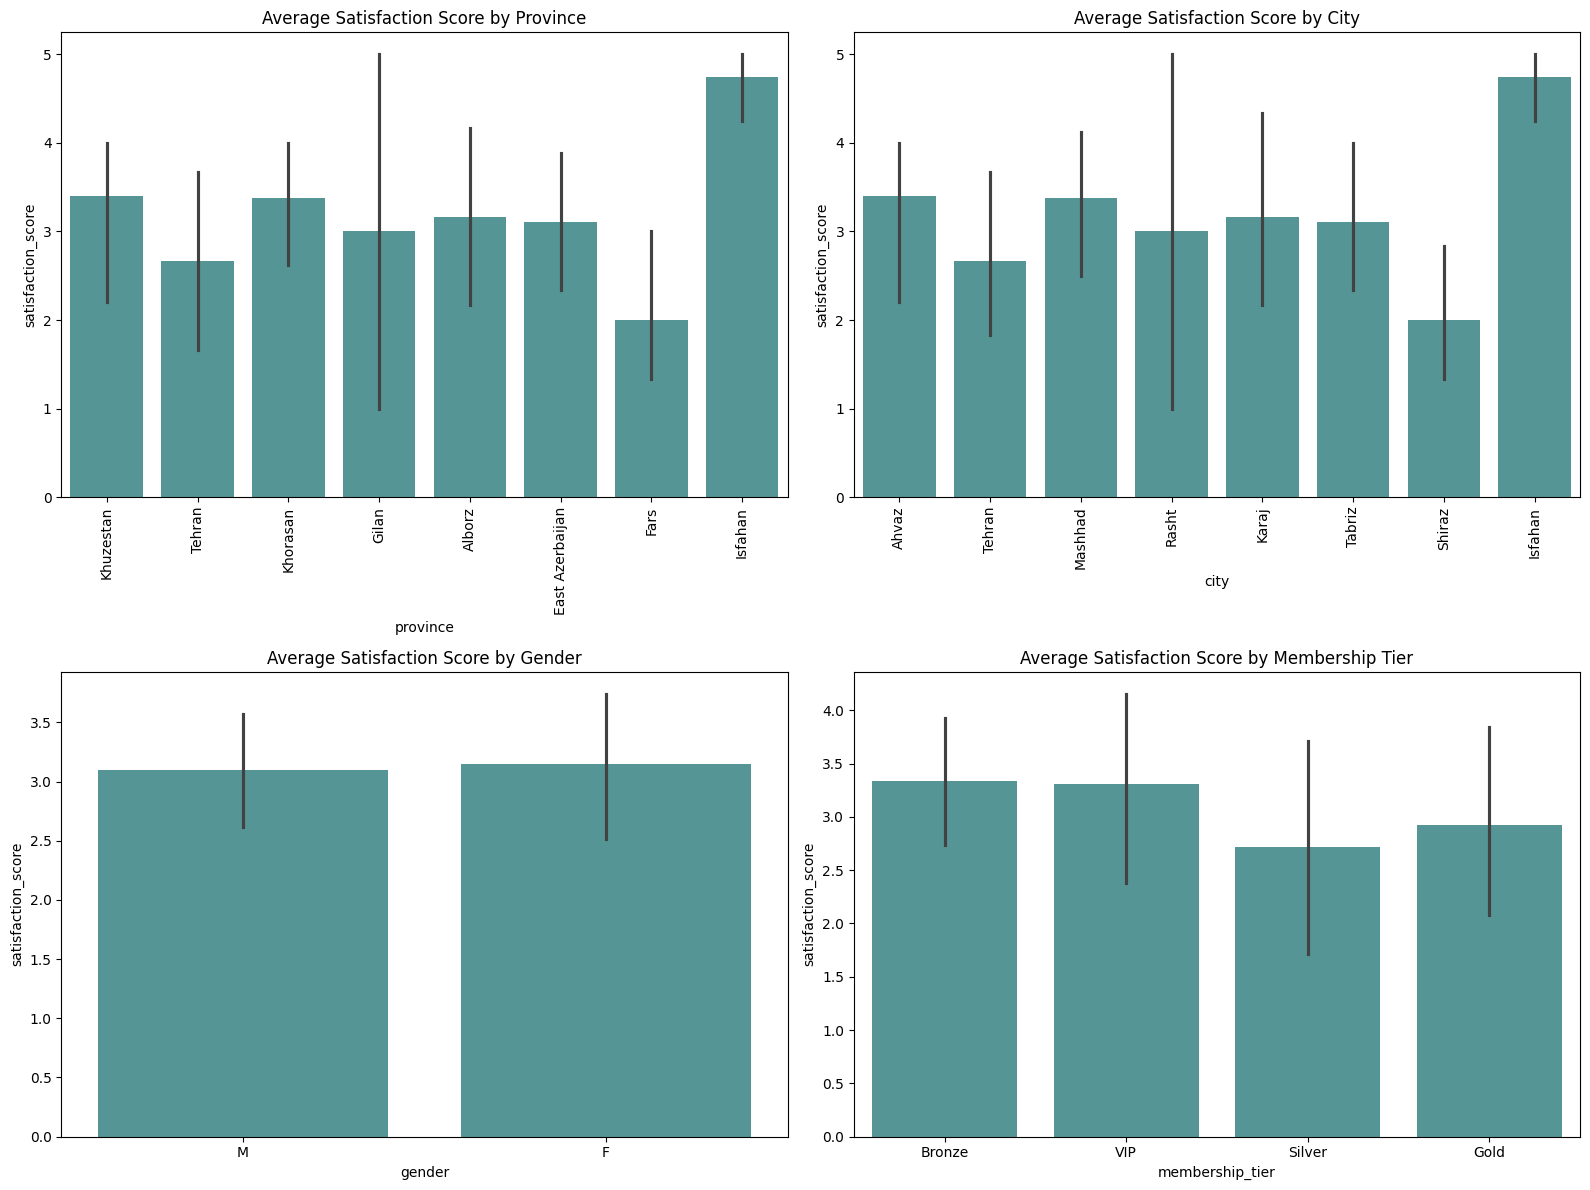

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Satisfaction score by Province
sns.barplot(
    data=Final_data,
    x='province',
    y='satisfaction_score',
    estimator='mean',
    color='#4C9F9F',
    ax=axes[0, 0]
)
axes[0, 0].set_title("Average Satisfaction Score by Province")
axes[0, 0].tick_params(axis='x', rotation=90)


# 2. Satisfaction score by City
sns.barplot(
    data=Final_data,
    x='city',
    y='satisfaction_score',
    estimator='mean',
    color='#4C9F9F',
    ax=axes[0, 1]
)
axes[0, 1].set_title("Average Satisfaction Score by City")
axes[0, 1].tick_params(axis='x', rotation=90)


# 3. Satisfaction score by Gender
sns.barplot(
    data=Final_data,
    x='gender',
    y='satisfaction_score',
    estimator='mean',
    color='#4C9F9F',
    ax=axes[1, 0]
)
axes[1, 0].set_title("Average Satisfaction Score by Gender")


# 4. Satisfaction score by Membership Tier
sns.barplot(
    data=Final_data,
    x='membership_tier',
    y='satisfaction_score',
    estimator='mean',
    color='#4C9F9F',
    ax=axes[1, 1]
)
axes[1, 1].set_title("Average Satisfaction Score by Membership Tier")


plt.tight_layout()
plt.show()

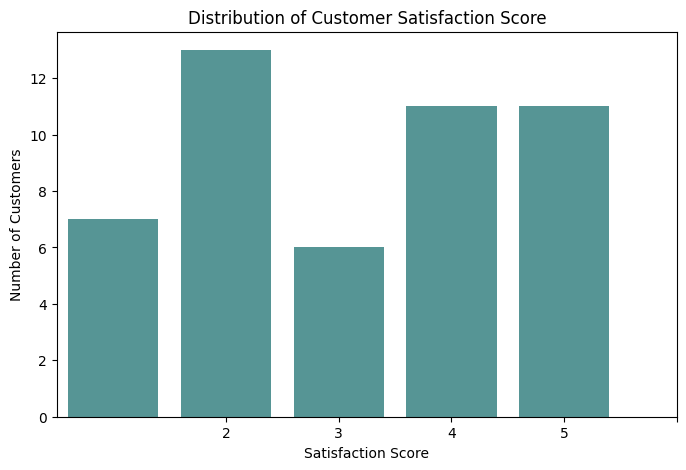

In [71]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=Final_data,
    x='satisfaction_score',
    color='#4C9F9F'
)

plt.title("Distribution of Customer Satisfaction Score")
plt.xlabel("Satisfaction Score")
plt.ylabel("Number of Customers")

plt.xticks(sorted(Final_data['satisfaction_score'].unique()))

plt.show()

In [72]:
Gender_counts=Final_data['gender'].value_counts()
membership_tier_counts=Final_data['membership_tier'].value_counts()

/tmp/ipykernel_1341/3076712641.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=Gender_counts.index,y=Gender_counts.values,ax=axes[0],palette="pastel")
/tmp/ipykernel_1341/3076712641.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=membership_tier_counts.index,y=membership_tier_counts.values,ax=axes[1],palette="muted")


Text(0, 0.5, 'Count')

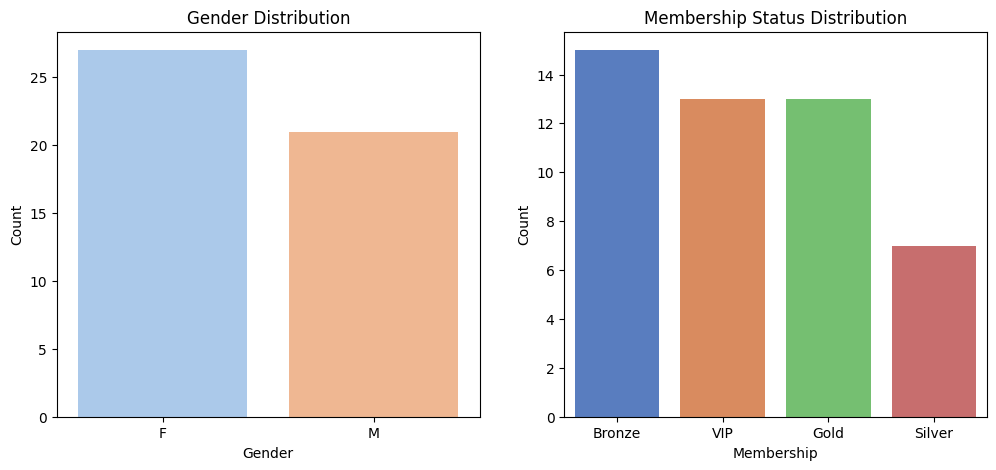

In [73]:
fig,axes=plt.subplots(1,2,figsize=(12,5))
plt.title("")
sns.barplot(x=Gender_counts.index,y=Gender_counts.values,ax=axes[0],palette="pastel")
sns.barplot(x=membership_tier_counts.index,y=membership_tier_counts.values,ax=axes[1],palette="muted")
axes[0].set_title("Gender Distribution")
axes[0].set_xlabel("Gender")
axes[0].set_ylabel("Count")
axes[1].set_title("Membership Status Distribution")
axes[1].set_xlabel("Membership")
axes[1].set_ylabel("Count")

In [74]:
numeric_data = Final_data.select_dtypes(include=[np.number])
corr_matrix=numeric_data.corr()

<Axes: title={'center': 'The corrolation between Numeric Features'}>

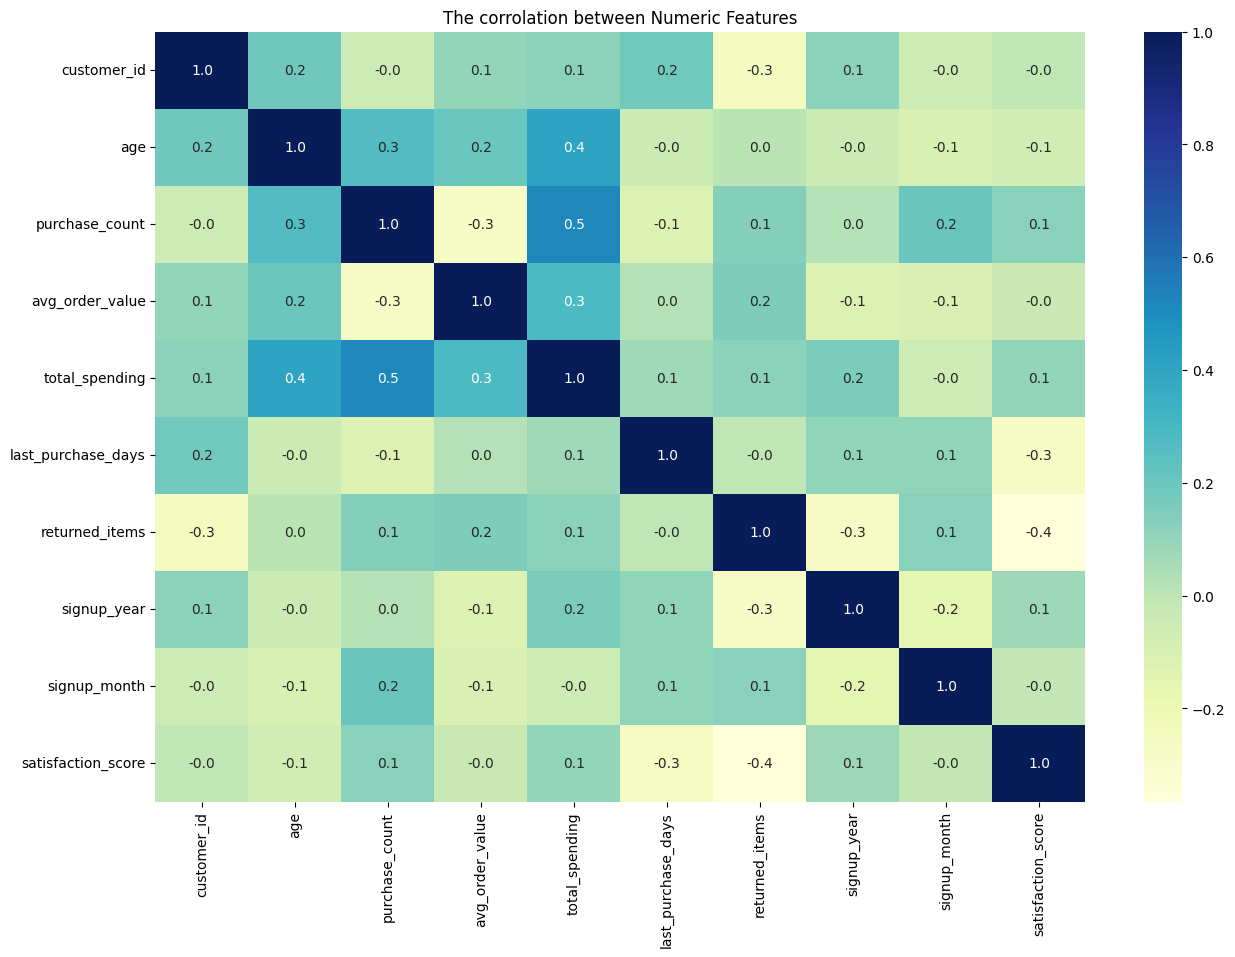

In [75]:
plt.figure(figsize=(15,10))
plt.title("The corrolation between Numeric Features")
sns.heatmap(data=corr_matrix,annot=True,cmap="YlGnBu", fmt=".1f")

/tmp/ipykernel_1341/2375622328.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=Final_data,x='avg_order_value',hue='membership_tier',shade=True)


<Axes: title={'center': 'Density of Average Order Value for different Membership types'}, xlabel='avg_order_value', ylabel='Density'>

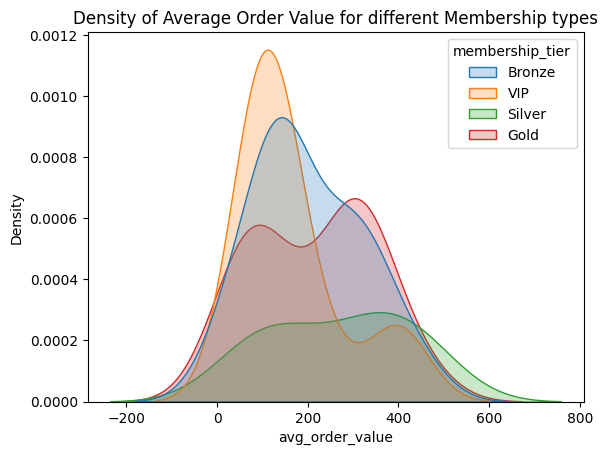

In [76]:
plt.title("Density of Average Order Value for different Membership types")
sns.kdeplot(data=Final_data,x='avg_order_value',hue='membership_tier',shade=True)

Text(0.5, 1.0, 'The Relashionship between Total Spending & Purchase Count')

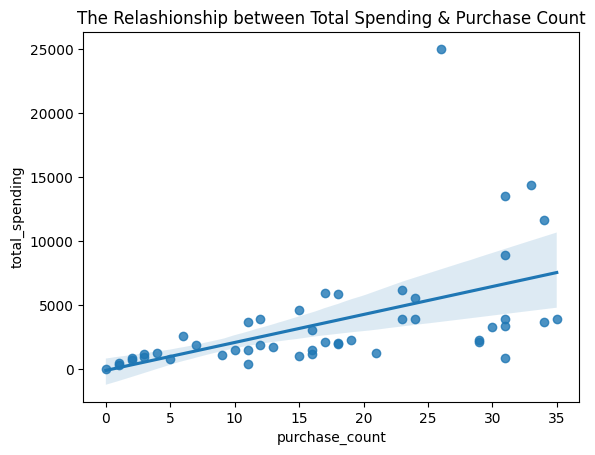

In [77]:
sns.regplot(x=Final_data['purchase_count'],y=Final_data['total_spending'])
plt.title("The Relashionship between Total Spending & Purchase Count")

Text(0.5, 1.0, 'The Relashionship between Total Spending & Payment Method')

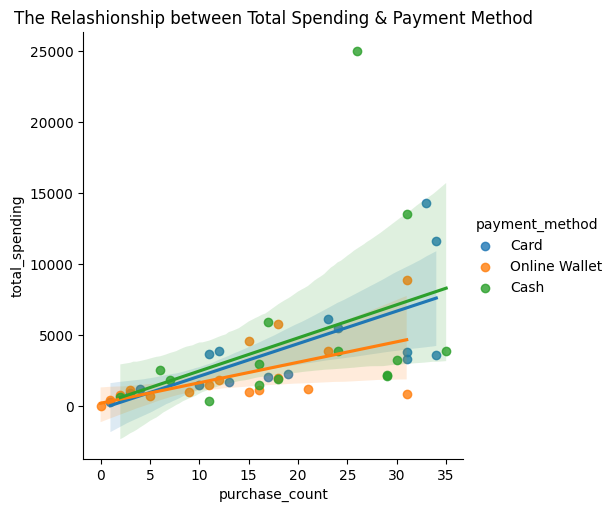

In [78]:
sns.lmplot(x='purchase_count',y='total_spending',hue='payment_method',data=Final_data)
plt.title("The Relashionship between Total Spending & Payment Method")

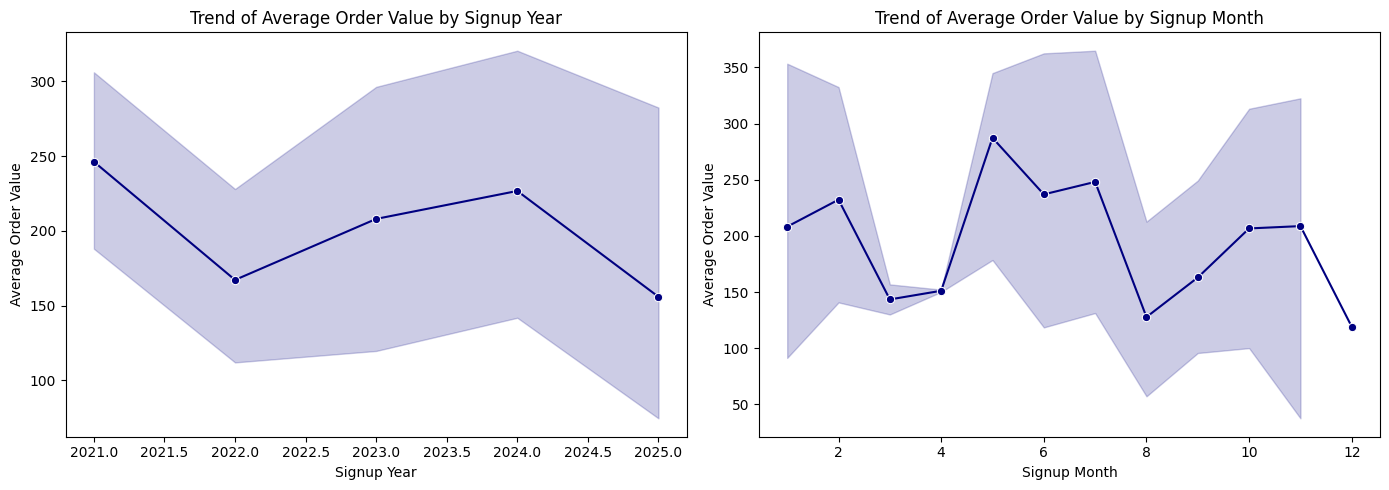

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(
    data=Final_data,
    x='signup_year',
    y='avg_order_value',
    estimator='mean',
    marker='o',
    color='navy',
    ax=axes[0]
)

axes[0].set_title("Trend of Average Order Value by Signup Year")
axes[0].set_xlabel("Signup Year")
axes[0].set_ylabel("Average Order Value")


sns.lineplot(
    data=Final_data,
    x='signup_month',
    y='avg_order_value',
    estimator='mean',
    marker='o',
    color='navy',
    ax=axes[1]
)

axes[1].set_title("Trend of Average Order Value by Signup Month")
axes[1].set_xlabel("Signup Month")
axes[1].set_ylabel("Average Order Value")


plt.tight_layout()
plt.show()

<Axes: title={'center': 'The Relashionship between Membership Type & Total Spending'}, xlabel='membership_tier', ylabel='total_spending'>

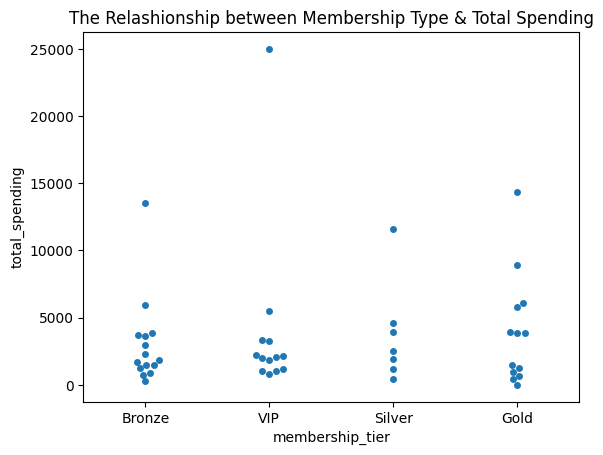

In [80]:
plt.title("The Relashionship between Membership Type & Total Spending")
sns.swarmplot(x=Final_data['membership_tier'],y=Final_data['total_spending'])

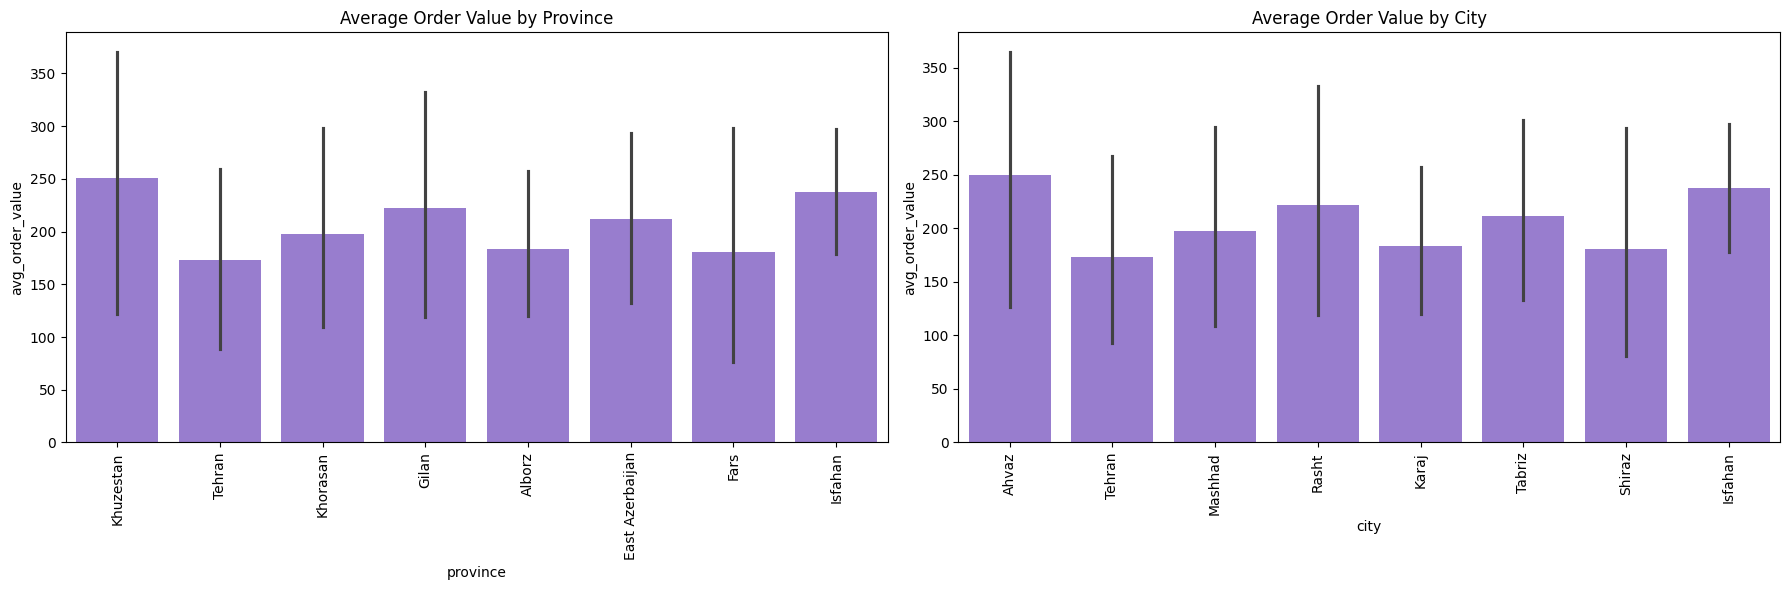

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(
    data=Final_data,
    x='province',
    y='avg_order_value',
    estimator='mean',
    color='mediumpurple',
    ax=axes[0]
)

axes[0].set_title("Average Order Value by Province")
axes[0].tick_params(axis='x', rotation=90)

sns.barplot(
    data=Final_data,
    x='city',
    y='avg_order_value',
    estimator='mean',
    color='mediumpurple',
    ax=axes[1]
)

axes[1].set_title("Average Order Value by City")
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()